# 🚚 DeliverIQ – Delivery Time Prediction
**End-to-end ML pipeline**: data cleaning → feature engineering → model training → evaluation → feature importance → deployment-ready export.

## 🔹 Step 1: Load Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Food_Delivery_Times.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 🔹 Step 2: Basic Inspection

In [2]:
print('=== Data Types & Non-Null Counts ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types & Non-Null Counts ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    str    
 3   Traffic_Level           970 non-null    str    
 4   Time_of_Day             970 non-null    str    
 5   Vehicle_Type            1000 non-null   str    
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 70.4 KB

=== Missing Values ===
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0


,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## 🔹 Step 3: Data Cleaning
- Drop `Order_ID` (identifier, not a predictor)
- Impute missing **categoricals** with **mode**
- Impute missing **numerics** with **median**

In [3]:
# Drop non-feature column
df.drop(columns=['Order_ID'], inplace=True)

# Impute categorical columns with mode
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numeric column with median
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

print('Missing values after cleaning:', df.isnull().sum().sum())
df.head()

Missing values after cleaning: 120


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


## 🔹 Step 4: Features & Target

In [4]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']
print(f'Features: {X.shape[1]} columns, {X.shape[0]} rows')
print(f'Target range: {y.min()} – {y.max()} minutes')

Features: 7 columns, 1000 rows
Target range: 8 – 153 minutes


## 🔹 Step 5: Encode Categorical Columns

In [5]:
X = pd.get_dummies(X, drop_first=True)
print(f'Encoded features: {X.shape[1]}')
print(list(X.columns))

Encoded features: 14
['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter']


## 🔹 Step 6: Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')

Training set : 800 samples
Test set     : 200 samples


## 🔹 Step 7: Train Model – Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


## 🔹 Step 8: Evaluate Model

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score

preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
r2  = r2_score(y_test, preds)

print(f'Mean Absolute Error (MAE) : {mae:.2f} minutes')
print(f'R² Score                  : {r2:.4f}')

Mean Absolute Error (MAE) : 7.09 minutes
R² Score                  : 0.7614


## 🔹 Step 9: Feature Importance

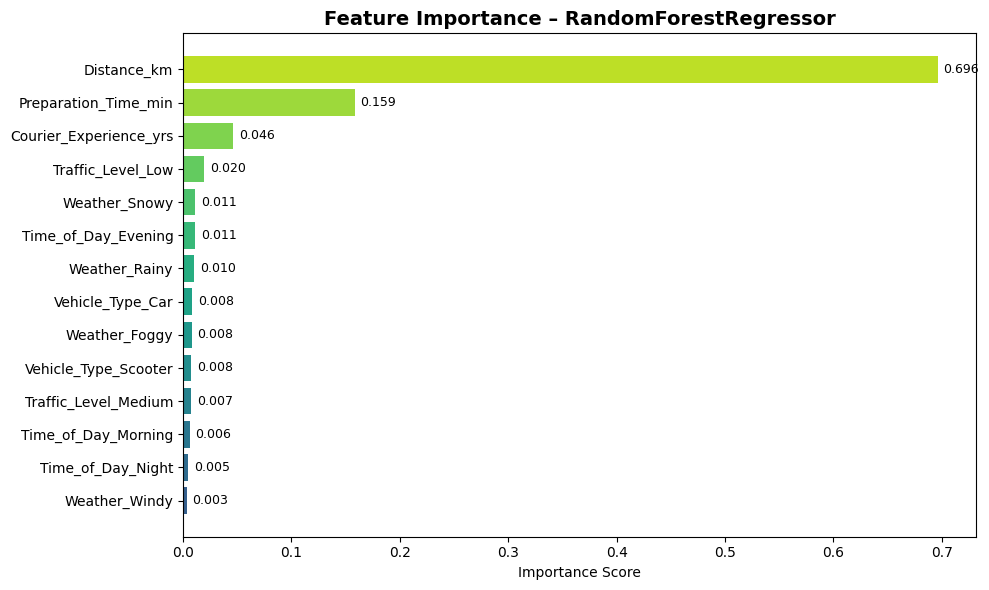

Chart saved as feature_importance.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
features    = X.columns

# Sort by importance
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(features)))
bars = ax.barh(features[sorted_idx], importances[sorted_idx], color=colors)
ax.set_title('Feature Importance – RandomForestRegressor', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as feature_importance.png')

## 🔹 Step 10: Save Model Artefacts

In [10]:
import pickle

# Save trained model
pickle.dump(model, open('model.pkl', 'wb'))

# Save feature column names (needed for web app alignment)
feature_columns = list(X.columns)
pickle.dump(feature_columns, open('feature_columns.pkl', 'wb'))

print('✅ Saved: model.pkl')
print('✅ Saved: feature_columns.pkl')
print(f'   → {len(feature_columns)} feature columns stored')

✅ Saved: model.pkl
✅ Saved: feature_columns.pkl
   → 14 feature columns stored
